# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

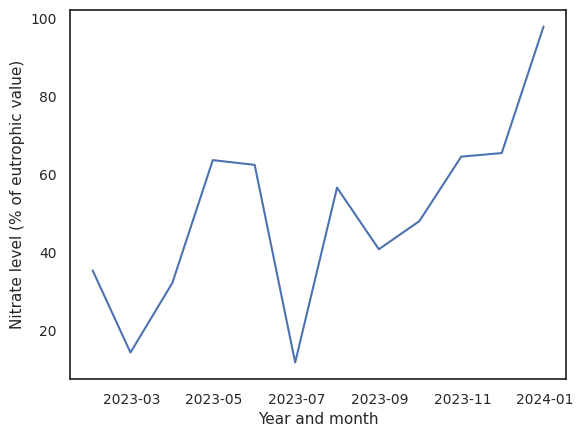

In [4]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

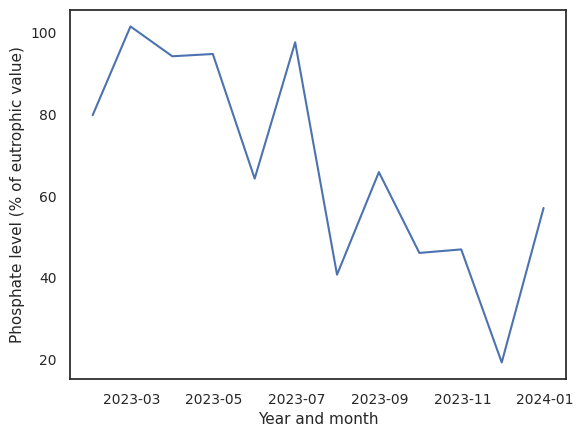

In [5]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

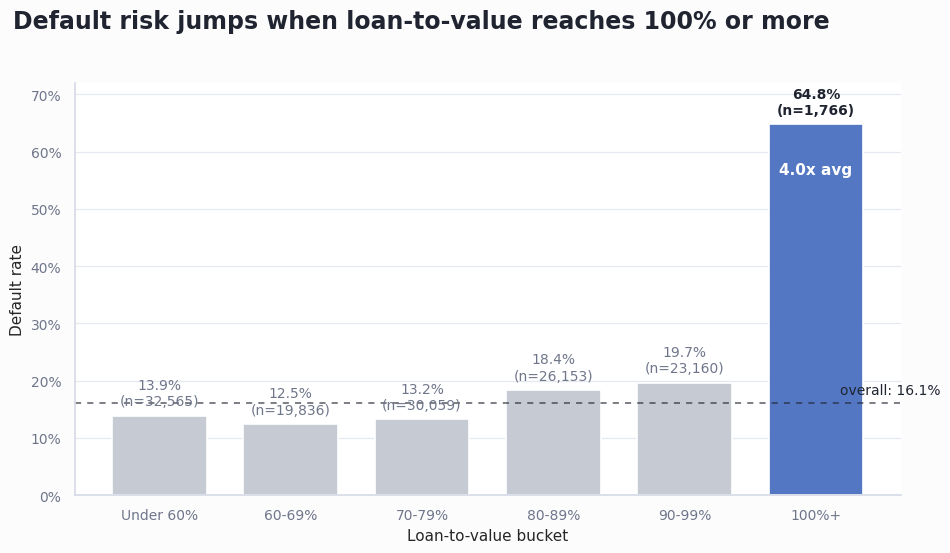

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

# Storytelling With Data plot using the loan default dataset.
# Analytical question: how does default risk change as loan-to-value rises?
# Takeaway: loans at 100%+ LTV default at a much higher rate than lower-LTV loans.
loans = pd.read_csv("DATA/Loan_Default.csv")

# Keep realistic LTV values for a cleaner, honest visual; the dataset has a few extreme LTV outliers.
plot_data = loans.loc[loans["LTV"].between(0, 150)].copy()
ltv_bins = [0, 60, 70, 80, 90, 100, 151]
ltv_labels = ["Under 60%", "60-69%", "70-79%", "80-89%", "90-99%", "100%+"]
plot_data["LTV bucket"] = pd.cut(
    plot_data["LTV"],
    bins=ltv_bins,
    labels=ltv_labels,
    right=False,
    include_lowest=True,
)

summary = (
    plot_data.dropna(subset=["LTV bucket"])
    .groupby("LTV bucket", observed=True)
    .agg(loans=("Status", "size"), defaults=("Status", "sum"), default_rate=("Status", "mean"))
    .reset_index()
)
summary["default_rate_pct"] = summary["default_rate"] * 100
overall_default_rate = plot_data["Status"].mean() * 100

# Storytelling With Data choices: remove clutter, use one highlight color, label directly.
sns.set_theme(style="white")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

surface = "#FCFCFD"
panel = "#FFFFFF"
ink = "#1F2430"
muted = "#6F768A"
grid = "#E6E8F0"
axis = "#D7DBE7"
blue = "#5477C4"
light_blue = "#CEDFFE"
neutral = "#C5CAD3"

colors = [blue if bucket == "100%+" else neutral for bucket in summary["LTV bucket"].astype(str)]

fig, ax = plt.subplots(figsize=(10.5, 6.2), facecolor=surface)
ax.set_facecolor(panel)

bars = ax.bar(
    summary["LTV bucket"].astype(str),
    summary["default_rate_pct"],
    color=colors,
    edgecolor=panel,
    linewidth=1.2,
    width=0.72,
)

# Direct labels remove the need for a legend and make the key comparison immediate.
for bar, rate, n in zip(bars, summary["default_rate_pct"], summary["loans"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f"{rate:.1f}%\n(n={n:,.0f})",
        ha="center",
        va="bottom",
        fontsize=10,
        color=ink if rate >= 30 else muted,
        fontweight="bold" if rate >= 30 else "normal",
    )

ax.axhline(overall_default_rate, color=ink, linewidth=1.1, linestyle=(0, (4, 4)), alpha=0.75)
ax.text(
    len(summary) - 0.05,
    overall_default_rate + 1.0,
    f"overall: {overall_default_rate:.1f}%",
    ha="right",
    va="bottom",
    fontsize=10,
    color=ink,
)

highlight_rate = summary.loc[summary["LTV bucket"].astype(str).eq("100%+"), "default_rate_pct"].iloc[0]
ax.text(
    5,
    highlight_rate - 8,
    f"{highlight_rate / overall_default_rate:.1f}x avg",
    ha="center",
    va="center",
    fontsize=11,
    color="white",
    fontweight="bold",
)

fig.text(
    0.08,
    0.95,
    "Default risk jumps when loan-to-value reaches 100% or more",
    ha="left",
    va="top",
    fontsize=17,
    fontweight="bold",
    color=ink,
)


ax.set_xlabel("Loan-to-value bucket")
ax.set_ylabel("Default rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 72)
ax.grid(axis="y", color=grid, linewidth=0.9)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(axis)
ax.spines["bottom"].set_color(axis)
ax.tick_params(axis="both", colors=muted)

plt.tight_layout(rect=[0.06, 0.06, 0.98, 0.86])
plt.show()